In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.ensemble import RandomForestClassifier

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

# 精度評価
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyClassifier 
import lightgbm as lgb
import optuna

In [73]:
train = pd.read_csv('../../data/processed/train_active_products.csv')
test = pd.read_csv('../../data/processed/test_active_products.csv')

In [74]:
# 説明変数と目的変数に分割

# 説明変数
X = train.drop(['Exited'],axis=1)
# 目的変数
y = train['Exited']

In [75]:
# データの分割
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=y)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (11250, 24), X_test: (3750, 24)


## 複数のモデルでROCを比較

In [76]:
clf = LazyClassifier(ignore_warnings=True, predictions=True)   #設定
models, predictions = clf.fit(X_train, X_test, y_train, y_test) #実行

In [77]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.847733,0.847483,0.917918,0.856921,0.880786,0.847733,0.098125
BernoulliNB,0.871733,0.843114,0.914590,0.876199,0.884734,0.871733,0.098858
LGBMClassifier,0.898133,0.825671,0.931237,0.896225,0.895265,0.898133,0.311051
LogisticRegression,0.899733,0.821329,0.929790,0.897053,0.896257,0.899733,0.113007
AdaBoostClassifier,0.900000,0.821010,0.929562,0.897239,0.896483,0.900000,1.018076
LinearSVC,0.900267,0.819233,0.929546,0.897246,0.896618,0.900267,0.129281
CalibratedClassifierCV,0.899467,0.819217,0.929581,0.896572,0.895846,0.899467,0.341744
LinearDiscriminantAnalysis,0.892800,0.816488,0.923860,0.890672,0.889588,0.892800,0.111333
RandomForestClassifier,0.892800,0.809682,0.920893,0.889809,0.888820,0.892800,1.824969


## LightGBMを用いてモデルを作成する

In [78]:
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test)

params = {
    'objective': 'binary',
    'metrics': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.01   
}

model = lgb.train(params, dtrain, num_boost_round=1000)
pred_prob = model.predict(X_test)

## Optunaを用いてhyper parameterのチューニングを行う

In [79]:
# 目的関数の定義
def objective(trial):
    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_test, y_test)

    params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'lambda_l1'         : trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2'         : trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),

        'force_col_wise':True,
        'random_state': 0,
    }

    model = lgb.train(
        params=params,
        train_set=dtrain,
        num_boost_round=100,
    )

    pred = model.predict(X_test, num_iteration=model.best_iteration)
    score = roc_auc_score(y_test, pred)
    
    return score

In [80]:
# 最適化の実行
optuna.logging.disable_default_handler()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), )
study.optimize(objective, n_trials=60)

In [81]:
# 最も精度の高いパラメータ
print('＝＝＝＝ベストパラメーター＝＝＝＝＝')
print(study.best_params)

# 最も精度の高いパラメータで学習を再度実行
best_params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1
    }
best_params.update(study.best_params)

＝＝＝＝ベストパラメーター＝＝＝＝＝
{'lambda_l1': 3.272619134382992e-06, 'lambda_l2': 2.170630744039105e-08, 'learning_rate': 0.15731286252118507, 'num_leaves': 6, 'feature_fraction': 0.4283288430140439, 'bagging_fraction': 0.6651114765373755, 'bagging_freq': 6, 'min_child_samples': 69}


## 層化K分割を用いてクロスバリデーションを行い、モデルの性能を評価する

In [82]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
valid_score = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_index], X.iloc[valid_index]
    y_tr, y_va = y.iloc[train_index], y.iloc[valid_index]
    set_tr = lgb.Dataset(X_tr, y_tr)
    
    model_tmp = lgb.train(
        params = best_params,
        train_set = set_tr
    )

    pred = model_tmp.predict(X_va)
    roc_score = roc_auc_score(y_va, pred)
    valid_score.append(roc_score)

    print(f'fold:{fold + 1} roc_score: {roc_score}')

cv_score = np.mean(valid_score)
print(f'cv_score: {cv_score}')

fold:1 roc_score: 0.9348331390065797
fold:2 roc_score: 0.9379526308010642
fold:3 roc_score: 0.9366450307091012
fold:4 roc_score: 0.931957582027786
fold:5 roc_score: 0.9332203638015788
cv_score: 0.9349217492692221


In [83]:
best_model = lgb.train(
    params = best_params,
    train_set = dtrain
)

pd.DataFrame(best_model.feature_importance(), index=X_train.columns )

,0
CreditScore,67
Age,75
Tenure,28
Balance,67
EstimatedSalary,65
is_young_stable,6
is_active_churn,5
is_peak_churn,12
is_senior_retire,0
is_prod1_inactive,10


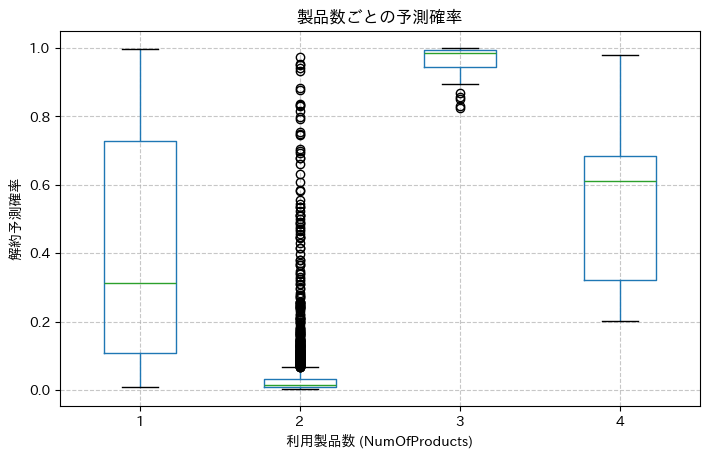

In [84]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. テストデータに対する予測確率を取得
y_test_proba = best_model.predict(X_test)

# 2. X_testのコピーを作成し、予測確率を追加
X_test_check = X_test.copy()
X_test_check['pred_proba'] = y_test_proba

# --------------------------------------------------
# 【修正】'2.0' のような小数点文字列を安全に整数に変換する
# --------------------------------------------------
# 列名に 'NumOfProducts_' が含まれる列（ダミー変数）を自動で全取得
products_columns = [col for col in X_test_check.columns if 'NumOfProducts_' in str(col)]

# 1が入っている列名を探し、数値を復元
X_test_check['NumOfProducts'] = (
    X_test_check[products_columns]
    .idxmax(axis=1)
    .astype(str)
    .str.replace('NumOfProducts_', '')
    .astype(float)  # 【重要】先に '2.0' を 2.0 (float型) に変換
    .astype(int)    # そのあと 2.0 を 2 (int型) に変換
)
# --------------------------------------------------

# 3. 製品数ごとの予測確率の分布を描画
X_test_check.boxplot(column='pred_proba', by='NumOfProducts', figsize=(8, 5))
plt.title('製品数ごとの予測確率')
plt.xlabel('利用製品数 (NumOfProducts)')
plt.ylabel('解約予測確率')
plt.suptitle('') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 学習済みモデルを用いてテストデータを予測

In [85]:
# 1. 欠損値を埋める
test_encoded = test.fillna(0)

# 2. 提出用の「確率」を予測する (predict ではなく predict_proba)
# ※学習時と同じ列にするため、もし 'id' や 'Exited' が残っていれば drop してください
X_test_final = test_encoded.drop(columns=['id', 'Exited'], errors='ignore')
pred_proba = best_model.predict(X_test_final)

In [86]:
np.savetxt('../../model/pred_test_proba_active_products.txt', pred_proba)

print("予測確率の保存が完了しました。左のフォルダから 'pred_test_proba_active_products.txt' をダウンロードするか、次のファイルで読み込んでください。")

予測確率の保存が完了しました。左のフォルダから 'pred_test_proba_active_products.txt' をダウンロードするか、次のファイルで読み込んでください。
